In [1]:
from iertools.read import read_sql
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
f = "../osm/004_dos_zonas/run/eplusout.sql"
base = read_sql(f,alias=True).data
base

variable_name,ESTE:Zone Air Relative Humidity (%),ESTE:Zone Air Temperature (C),Ti_ESTE,To,OESTE:Zone Air Relative Humidity (%),OESTE:Zone Air Temperature (C),Ti_OESTE,TECHO:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2),VNORTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2),VOESTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)
date,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,24.692687,17.566667,NaN,NaN,25.746551,0.0,0.0,0.0
2006-01-01 00:20:00,NaN,NaN,24.587666,17.733333,NaN,NaN,25.609811,0.0,0.0,0.0
2006-01-01 00:30:00,NaN,NaN,24.484601,17.900000,NaN,NaN,25.474863,0.0,0.0,0.0
2006-01-01 00:40:00,NaN,NaN,24.383016,18.066667,NaN,NaN,25.341520,0.0,0.0,0.0
2006-01-01 00:50:00,NaN,NaN,24.282393,18.233333,NaN,NaN,25.209956,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,26.946094,19.833333,NaN,NaN,28.404442,0.0,0.0,0.0
2006-12-31 23:30:00,NaN,NaN,26.834170,19.500000,NaN,NaN,28.259459,0.0,0.0,0.0
2006-12-31 23:40:00,NaN,NaN,26.724276,19.166667,NaN,NaN,28.116413,0.0,0.0,0.0


In [3]:
To_m = base.To.groupby(base.index.month).mean()
Tn_m = 13.5 + 0.54*To_m
Tn_m

date
1     24.986684
2     25.996846
3     26.777198
4     28.177624
5     28.116815
6     26.929054
7     26.537248
8     26.584363
9     26.086521
10    26.123257
11    25.322611
12    25.150088
Name: To, dtype: float64

In [4]:
banda = 1.25
dt_h = 1/6
Tn_serie = pd.Series(base.index.month.map(Tn_m),index=base.index)
Tn_sup = Tn_serie + banda
Tn_inf = Tn_serie - banda
Ti = base["Ti_ESTE"]

In [5]:
GHDC = (Ti - Tn_sup).clip(lower=0).sum()*dt_h
GHDF = (Tn_inf - Ti).clip(lower=0).sum()*dt_h
GHDC,GHDF

(np.float64(6884.50868858365), np.float64(5001.397121736702))

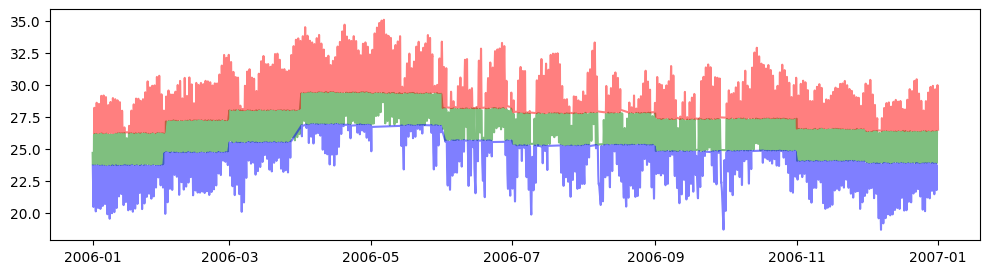

In [6]:
confort = (Ti >= Tn_inf) & (Ti <= Tn_sup)
calor = (Ti > Tn_sup)
frio  = (Ti < Tn_inf) 

fig, ax = plt.subplots(figsize=(12,3))

ax.plot(Ti[confort],color='green',alpha=0.5,label="confort")
ax.plot(Ti[calor],color='red',alpha=0.5,label="calor")
ax.plot(Ti[frio],color='blue',alpha=0.5,label="frio")
# ax.plot(base.Ti_ESTE) # la descomento para verificar